# Five-Model Performance Comparison

## Smart Waste Classification System Using Deep Learning

This notebook consolidates and compares the five image-classification
architectures developed for the TrashNet waste-classification problem:

1. Baseline CNN
2. ResNet50
3. EfficientNet-B0
4. DenseNet121
5. MobileNetV3-Large

The comparison considers both predictive and deployment-related evidence:

- Test accuracy
- Weighted precision
- Weighted recall
- Weighted F1-score
- Macro F1-score
- ROC-AUC
- Model size
- Parameter count
- CPU inference latency
- Predictions per second
- Per-class performance
- Error patterns

The purpose of this notebook is to identify the strongest candidate models for
hyperparameter tuning. It does not make the final production-model decision,
because explainability and tuned-model evidence must also be considered.

##  Comparison Objectives

The objectives of this notebook are to:

1. Load the saved result records from all five model experiments.
2. Standardize inconsistent column names where necessary.
3. Validate that all models were evaluated on the same test dataset.
4. Compare predictive performance.
5. Compare deployment efficiency.
6. Rank models using individual metrics.
7. Examine accuracy-versus-latency and accuracy-versus-size trade-offs.
8. Identify the two strongest candidates for hyperparameter tuning.
9. Document limitations that prevent immediate final-model selection.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

##  Comparison Configuration

All experiment result files are expected to exist under the project `results`
directory.

The comparison notebook reads previously generated results rather than
recalculating metrics. This keeps model evaluation separate from comparison and
prevents accidental test-set re-evaluation.

In [2]:
PROJECT_ROOT = Path("..")

RESULTS_DIRECTORY = (
    PROJECT_ROOT / "results"
)

FIGURES_DIRECTORY = (
    RESULTS_DIRECTORY / "figures"
)

FIGURES_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

COMPARISON_OUTPUT_PATH = (
    RESULTS_DIRECTORY
    / "five_model_comparison.csv"
)

MODEL_RANKING_PATH = (
    RESULTS_DIRECTORY
    / "five_model_ranking.csv"
)

print(
    "Results directory:",
    RESULTS_DIRECTORY.resolve(),
)

Results directory: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results


In [37]:
available_comparison_files = sorted(
    RESULTS_DIRECTORY.glob(
        "*comparison_row.csv"
    )
)

print(
    f"Comparison-row files found: "
    f"{len(available_comparison_files)}"
)

for file_path in (
    available_comparison_files
):
    print(file_path.name)

Comparison-row files found: 5
baseline_cnn_comparison_row.csv
densenet121_comparison_row.csv
efficientnet_b0_comparison_row.csv
mobilenet_v3_large_comparison_row.csv
resnet50_comparison_row.csv


In [35]:
EXPECTED_COMPARISON_FILES = {
    "Baseline CNN": (
        RESULTS_DIRECTORY
        / "baseline_cnn_comparison_row.csv"
    ),
    "ResNet50": (
        RESULTS_DIRECTORY
        / "resnet50_comparison_row.csv"
    ),
    "EfficientNet-B0": (
        RESULTS_DIRECTORY
        / "efficientnet_b0_comparison_row.csv"
    ),
    "DenseNet121": (
        RESULTS_DIRECTORY
        / "densenet121_comparison_row.csv"
    ),
    "MobileNetV3-Large": (
        RESULTS_DIRECTORY
        / "mobilenet_v3_large_comparison_row.csv"
    ),
}

comparison_file_status = pd.DataFrame(
    [
        {
            "model_name": model_name,
            "file_path": str(file_path),
            "exists": file_path.exists(),
        }
        for model_name, file_path
        in EXPECTED_COMPARISON_FILES.items()
    ]
)

comparison_file_status

,model_name,file_path,exists
0,Baseline CNN,..\results\baseline_cnn_comparison_row.csv,True
1,ResNet50,..\results\resnet50_comparison_row.csv,True
2,EfficientNet-B0,..\results\efficientnet_b0_comparison_row.csv,True
3,DenseNet121,..\results\densenet121_comparison_row.csv,True
4,MobileNetV3-Large,..\results\mobilenet_v3_large_comparison_row.csv,True


In [36]:
all_result_files = sorted(
    list(
        RESULTS_DIRECTORY.glob("*.json")
    )
    + list(
        RESULTS_DIRECTORY.glob("*.csv")
    )
)

for file_path in all_result_files:
    print(file_path.name)

baseline_cnn_comparison_row.csv
densenet121_class_confusions.csv
densenet121_classification_report.csv
densenet121_comparison_row.csv
densenet121_confusion_matrix.csv
densenet121_final_results.json
densenet121_high_confidence_errors.csv
densenet121_per_class_results.csv
densenet121_prediction_distribution.csv
densenet121_test_predictions.csv
efficientnet_b0_class_confusions.csv
efficientnet_b0_classification_report.csv
efficientnet_b0_comparison_row.csv
efficientnet_b0_confusion_matrix.csv
efficientnet_b0_final_results.json
efficientnet_b0_fine_tuning_configuration.json
efficientnet_b0_frozen_configuration.json
efficientnet_b0_high_confidence_errors.csv
efficientnet_b0_low_confidence_correct.csv
efficientnet_b0_per_class_results.csv
efficientnet_b0_prediction_distribution.csv
efficientnet_b0_test_predictions.csv
mobilenet_v3_large_class_confusions.csv
mobilenet_v3_large_classification_report.csv
mobilenet_v3_large_comparison_row.csv
mobilenet_v3_large_confusion_matrix.csv
mobilenet_v3_

In [38]:
comparison_rows = []

for model_name, file_path in (
    EXPECTED_COMPARISON_FILES.items()
):
    if not file_path.exists():
        continue

    model_row = pd.read_csv(
        file_path
    )

    if len(model_row) != 1:
        raise ValueError(
            f"{file_path.name} should contain "
            "exactly one row."
        )

    if "model_name" not in (
        model_row.columns
    ):
        model_row[
            "model_name"
        ] = model_name

    comparison_rows.append(
        model_row
    )

if comparison_rows:
    partial_comparison = pd.concat(
        comparison_rows,
        ignore_index=True,
        sort=False,
    )

    display(
        partial_comparison
    )
else:
    raise FileNotFoundError(
        "No standardized comparison rows "
        "were found."
    )

,model_name,architecture,training_stage,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,...,macro_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,predictions_per_second,best_validation_accuracy,best_validation_loss,test_sample_count,weighted_roc_auc,median_inference_latency_ms
0,Baseline CNN,custom_baseline_cnn,supervised_training,NaN,0.559055,0.634975,0.559055,0.567976,0.597956,0.578335,...,0.877432,1.098040,NaN,37.945976,26.353255,0.529101,NaN,381.0,NaN,NaN
1,ResNet50,resnet50,frozen_feature_extraction,NaN,0.876640,0.887830,0.876640,0.878060,0.853201,0.861369,...,0.987946,90.124084,23520326.0,163.094847,6.131402,0.843915,NaN,381.0,NaN,NaN
2,EfficientNet-B0,efficientnet_b0,controlled_fine_tuning,0.427249,0.853018,0.862567,0.853018,0.854954,0.830075,0.841130,...,0.982026,24.230475,4015234.0,39.156232,25.538719,0.806878,0.558372,NaN,0.981699,37.78455
3,DenseNet121,densenet121,NaN,0.433801,0.829396,0.838518,0.829396,0.830542,NaN,NaN,...,0.981981,43.458006,6960006.0,159.790327,6.258201,0.857143,0.442937,NaN,NaN,151.44305
4,MobileNetV3-Large,mobilenet_v3_large,controlled_fine_tuning,0.407010,0.881890,0.884323,0.881890,0.881512,0.880560,0.864359,...,0.987222,16.257907,4209718.0,26.876483,37.207249,0.875661,0.407661,NaN,0.986493,25.55970


In [39]:
COLUMN_RENAME_MAP = {
    "weighted_f1": (
        "weighted_f1_score"
    ),
    "macro_f1": (
        "macro_f1_score"
    ),
    "mean_latency_ms": (
        "mean_inference_latency_ms"
    ),
    "median_latency_ms": (
        "median_inference_latency_ms"
    ),
    "checkpoint_size_mb": (
        "model_size_mb"
    ),
    "deployment_model_size_mb": (
        "model_size_mb"
    ),
}

partial_comparison = (
    partial_comparison.rename(
        columns=COLUMN_RENAME_MAP
    )
)

duplicate_columns = (
    partial_comparison.columns[
        partial_comparison.columns
        .duplicated()
    ]
    .tolist()
)

if duplicate_columns:
    raise ValueError(
        "Duplicate standardized columns "
        "were created: "
        + ", ".join(
            duplicate_columns
        )
    )

partial_comparison

,model_name,architecture,training_stage,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,...,macro_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,predictions_per_second,best_validation_accuracy,best_validation_loss,test_sample_count,weighted_roc_auc,median_inference_latency_ms
0,Baseline CNN,custom_baseline_cnn,supervised_training,NaN,0.559055,0.634975,0.559055,0.567976,0.597956,0.578335,...,0.877432,1.098040,NaN,37.945976,26.353255,0.529101,NaN,381.0,NaN,NaN
1,ResNet50,resnet50,frozen_feature_extraction,NaN,0.876640,0.887830,0.876640,0.878060,0.853201,0.861369,...,0.987946,90.124084,23520326.0,163.094847,6.131402,0.843915,NaN,381.0,NaN,NaN
2,EfficientNet-B0,efficientnet_b0,controlled_fine_tuning,0.427249,0.853018,0.862567,0.853018,0.854954,0.830075,0.841130,...,0.982026,24.230475,4015234.0,39.156232,25.538719,0.806878,0.558372,NaN,0.981699,37.78455
3,DenseNet121,densenet121,NaN,0.433801,0.829396,0.838518,0.829396,0.830542,NaN,NaN,...,0.981981,43.458006,6960006.0,159.790327,6.258201,0.857143,0.442937,NaN,NaN,151.44305
4,MobileNetV3-Large,mobilenet_v3_large,controlled_fine_tuning,0.407010,0.881890,0.884323,0.881890,0.881512,0.880560,0.864359,...,0.987222,16.257907,4209718.0,26.876483,37.207249,0.875661,0.407661,NaN,0.986493,25.55970


##  Standardized Comparison Schema

Every model should provide the same core evidence.

Predictive metrics measure classification quality, while deployment metrics
measure whether the model is practical for a production API.

A model will not be ranked using accuracy alone.

In [9]:
REQUIRED_COMPARISON_COLUMNS = [
    "model_name",
    "test_loss",
    "test_accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1_score",
    "macro_f1_score",
    "macro_roc_auc",
    "model_size_mb",
    "total_parameters",
    "mean_inference_latency_ms",
    "predictions_per_second",
]

available_required_columns = [
    column
    for column
    in REQUIRED_COMPARISON_COLUMNS
    if column in partial_comparison.columns
]

missing_required_columns = [
    column
    for column
    in REQUIRED_COMPARISON_COLUMNS
    if column
    not in partial_comparison.columns
]

print(
    "Available required columns:"
)

print(
    available_required_columns
)

print(
    "\nMissing required columns:"
)

print(
    missing_required_columns
)

Available required columns:
['model_name', 'test_loss', 'test_accuracy', 'weighted_precision', 'weighted_recall', 'weighted_f1_score', 'macro_f1_score', 'macro_roc_auc', 'model_size_mb', 'total_parameters', 'mean_inference_latency_ms', 'predictions_per_second']

Missing required columns:
[]


In [10]:
def load_json_file(
    file_path: Path,
) -> dict:
    """
    Load a JSON experiment result file.
    """
    if not file_path.exists():
        raise FileNotFoundError(
            f"Result file not found: "
            f"{file_path.resolve()}"
        )

    with open(
        file_path,
        "r",
        encoding="utf-8",
    ) as input_file:
        return json.load(
            input_file
        )

In [27]:
REPORTS_DIRECTORY = (
    PROJECT_ROOT / "reports"
)

BASELINE_RESULTS_PATH = (
    REPORTS_DIRECTORY
    / "baseline"
    / "baseline_metrics.json"
)

RESNET50_RESULTS_PATH = (
    REPORTS_DIRECTORY
    / "transfer_learning"
    / "resnet50_initial"
    / "evaluation_metrics.json"
)

print("Baseline results path:")
print(BASELINE_RESULTS_PATH.resolve())
print("Exists:", BASELINE_RESULTS_PATH.exists())

print("\nResNet50 results path:")
print(RESNET50_RESULTS_PATH.resolve())
print("Exists:", RESNET50_RESULTS_PATH.exists())

Baseline results path:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\baseline\baseline_metrics.json
Exists: True

ResNet50 results path:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\transfer_learning\resnet50_initial\evaluation_metrics.json
Exists: True


In [13]:
baseline_metrics = load_json_file(
    BASELINE_RESULTS_PATH
)

print(
    json.dumps(
        baseline_metrics,
        indent=2,
    )
)

{
  "model_name": "baseline_cnn",
  "checkpoint_epoch": 15,
  "validation": {
    "accuracy": 0.5291005291005291,
    "macro_precision": 0.548933287576445,
    "macro_recall": 0.564074868358346,
    "macro_f1": 0.5191638380746465,
    "weighted_precision": 0.5842242891006576,
    "weighted_recall": 0.5291005291005291,
    "weighted_f1": 0.5379798499413997,
    "roc_auc_ovr_macro": 0.8692699179138857,
    "confusion_matrix": [
      [
        46,
        1,
        2,
        3,
        4,
        4
      ],
      [
        0,
        21,
        9,
        11,
        9,
        25
      ],
      [
        0,
        14,
        22,
        8,
        4,
        13
      ],
      [
        1,
        0,
        4,
        52,
        19,
        13
      ],
      [
        3,
        11,
        1,
        8,
        42,
        7
      ],
      [
        1,
        0,
        0,
        2,
        1,
        17
      ]
    ],
    "per_class_accuracy": {
      "cardboard": 0.7666666666

In [14]:
print("Top-level JSON keys:")
print(list(baseline_metrics.keys()))

print("\nSections and value types:")

for key, value in baseline_metrics.items():
    print(
        f"{key:<35}"
        f"{type(value).__name__}"
    )

Top-level JSON keys:
['model_name', 'checkpoint_epoch', 'validation', 'test']

Sections and value types:
model_name                         str
checkpoint_epoch                   int
validation                         dict
test                               dict


In [16]:
for section_name in [
    "validation",
    "test",
    "test_metrics",
    "evaluation",
    "inference",
    "deployment",
]:
    if section_name in baseline_metrics:
        print("=" * 72)
        print(section_name.upper())
        print("=" * 72)

        print(
            json.dumps(
                baseline_metrics[
                    section_name
                ],
                indent=2,
            )
        )

VALIDATION
{
  "accuracy": 0.5291005291005291,
  "macro_precision": 0.548933287576445,
  "macro_recall": 0.564074868358346,
  "macro_f1": 0.5191638380746465,
  "weighted_precision": 0.5842242891006576,
  "weighted_recall": 0.5291005291005291,
  "weighted_f1": 0.5379798499413997,
  "roc_auc_ovr_macro": 0.8692699179138857,
  "confusion_matrix": [
    [
      46,
      1,
      2,
      3,
      4,
      4
    ],
    [
      0,
      21,
      9,
      11,
      9,
      25
    ],
    [
      0,
      14,
      22,
      8,
      4,
      13
    ],
    [
      1,
      0,
      4,
      52,
      19,
      13
    ],
    [
      3,
      11,
      1,
      8,
      42,
      7
    ],
    [
      1,
      0,
      0,
      2,
      1,
      17
    ]
  ],
  "per_class_accuracy": {
    "cardboard": 0.7666666666666667,
    "glass": 0.28,
    "metal": 0.36065573770491804,
    "paper": 0.5842696629213483,
    "plastic": 0.5833333333333334,
    "trash": 0.8095238095238095
  },
  "classification_r

In [17]:
def find_value_recursively(
    data,
    candidate_keys: list[str],
):
    """
    Search nested dictionaries for the first matching key.

    Parameters
    ----------
    data:
        Dictionary or nested data structure.

    candidate_keys:
        Possible key names, ordered from most preferred
        to least preferred.

    Returns
    -------
    object or None
        First matching value, or None when no key is found.
    """
    if isinstance(data, dict):
        for candidate_key in candidate_keys:
            if candidate_key in data:
                return data[candidate_key]

        for nested_value in data.values():
            result = find_value_recursively(
                nested_value,
                candidate_keys,
            )

            if result is not None:
                return result

    elif isinstance(data, list):
        for item in data:
            result = find_value_recursively(
                item,
                candidate_keys,
            )

            if result is not None:
                return result

    return None

In [18]:
possible_test_section_names = [
    "test",
    "test_metrics",
    "evaluation",
    "test_evaluation",
]

baseline_test_metrics = None
baseline_test_section_name = None

for section_name in possible_test_section_names:
    if (
        section_name in baseline_metrics
        and isinstance(
            baseline_metrics[
                section_name
            ],
            dict,
        )
    ):
        baseline_test_metrics = (
            baseline_metrics[
                section_name
            ]
        )

        baseline_test_section_name = (
            section_name
        )

        break

if baseline_test_metrics is None:
    raise KeyError(
        "A test-metrics section could not be found "
        "inside baseline_metrics. Review the section "
        "names printed in the previous cell."
    )

print(
    "Baseline test section:",
    baseline_test_section_name,
)

print(
    json.dumps(
        baseline_test_metrics,
        indent=2,
    )
)

Baseline test section: test
{
  "accuracy": 0.5590551181102362,
  "macro_precision": 0.5979560342655581,
  "macro_recall": 0.5783354598082255,
  "macro_f1": 0.5420710833945607,
  "weighted_precision": 0.6349748741724744,
  "weighted_recall": 0.5590551181102362,
  "weighted_f1": 0.5679764063146212,
  "roc_auc_ovr_macro": 0.8774318462035252,
  "confusion_matrix": [
    [
      43,
      5,
      0,
      5,
      5,
      3
    ],
    [
      2,
      22,
      0,
      7,
      14,
      30
    ],
    [
      0,
      16,
      23,
      13,
      1,
      9
    ],
    [
      0,
      0,
      3,
      63,
      13,
      11
    ],
    [
      2,
      7,
      0,
      11,
      46,
      6
    ],
    [
      2,
      0,
      1,
      1,
      1,
      16
    ]
  ],
  "per_class_accuracy": {
    "cardboard": 0.7049180327868853,
    "glass": 0.29333333333333333,
    "metal": 0.3709677419354839,
    "paper": 0.7,
    "plastic": 0.6388888888888888,
    "trash": 0.7619047619047619
  },
 

In [19]:
baseline_test_loss = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "loss",
            "test_loss",
            "average_loss",
        ],
    )
)

baseline_test_accuracy = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "accuracy",
            "test_accuracy",
        ],
    )
)

baseline_weighted_precision = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "weighted_precision",
        ],
    )
)

baseline_weighted_recall = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "weighted_recall",
        ],
    )
)

baseline_weighted_f1 = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "weighted_f1",
            "weighted_f1_score",
        ],
    )
)

baseline_macro_precision = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "macro_precision",
        ],
    )
)

baseline_macro_recall = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "macro_recall",
        ],
    )
)

baseline_macro_f1 = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "macro_f1",
            "macro_f1_score",
        ],
    )
)

baseline_macro_roc_auc = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "roc_auc_ovr_macro",
            "macro_roc_auc",
        ],
    )
)

baseline_sample_count = (
    find_value_recursively(
        baseline_test_metrics,
        [
            "sample_count",
            "test_samples",
        ],
    )
)

In [40]:
baseline_validation_metrics = (
    baseline_metrics.get(
        "validation",
        {},
    )
)

baseline_best_validation_accuracy = (
    find_value_recursively(
        baseline_validation_metrics,
        [
            "accuracy",
            "best_validation_accuracy",
        ],
    )
)

baseline_best_validation_loss = (
    find_value_recursively(
        baseline_validation_metrics,
        [
            "loss",
            "best_validation_loss",
            "average_loss",
        ],
    )
)

baseline_checkpoint_epoch = (
    baseline_metrics.get(
        "checkpoint_epoch"
    )
)

print(
    "Checkpoint epoch:",
    baseline_checkpoint_epoch,
)

print(
    "Validation accuracy:",
    baseline_best_validation_accuracy,
)

print(
    "Validation loss:",
    baseline_best_validation_loss,
)

Checkpoint epoch: 15
Validation accuracy: 0.5291005291005291
Validation loss: None


In [21]:
average_inference_time_seconds = (
    find_value_recursively(
        baseline_metrics,
        [
            "average_inference_time_seconds",
        ],
    )
)

if average_inference_time_seconds is not None:
    baseline_mean_latency_ms = (
        float(
            average_inference_time_seconds
        )
        * 1000
    )

    baseline_predictions_per_second = (
        1.0
        / float(
            average_inference_time_seconds
        )
    )

else:
    baseline_mean_latency_ms = None
    baseline_predictions_per_second = None

print(
    "Average inference time (seconds):",
    average_inference_time_seconds,
)

print(
    "Mean inference latency (ms):",
    baseline_mean_latency_ms,
)

print(
    "Predictions per second:",
    baseline_predictions_per_second,
)

Average inference time (seconds): 0.03794597645508706
Mean inference latency (ms): 37.945976455087056
Predictions per second: 26.353255164842107


In [22]:
BASELINE_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "models"
    / "baseline_cnn_best.pt"
)

if not BASELINE_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "Baseline checkpoint was not found at:\n"
        f"{BASELINE_CHECKPOINT_PATH.resolve()}"
    )

baseline_model_size_mb = (
    BASELINE_CHECKPOINT_PATH.stat().st_size
    / (1024 ** 2)
)

print(
    "Baseline checkpoint path:"
)

print(
    BASELINE_CHECKPOINT_PATH.resolve()
)

print(
    f"Baseline checkpoint size: "
    f"{baseline_model_size_mb:.2f} MB"
)

Baseline checkpoint path:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\baseline_cnn_best.pt
Baseline checkpoint size: 1.10 MB


In [41]:
baseline_total_parameters = (
    find_value_recursively(
        baseline_metrics,
        [
            "total_parameters",
            "parameter_count",
            "model_parameters",
        ],
    )
)

print(
    "Baseline total parameters:",
    baseline_total_parameters,
)

Baseline total parameters: None


In [24]:
baseline_extracted_values = {
    "test_loss": (
        baseline_test_loss
    ),
    "test_accuracy": (
        baseline_test_accuracy
    ),
    "weighted_precision": (
        baseline_weighted_precision
    ),
    "weighted_recall": (
        baseline_weighted_recall
    ),
    "weighted_f1_score": (
        baseline_weighted_f1
    ),
    "macro_precision": (
        baseline_macro_precision
    ),
    "macro_recall": (
        baseline_macro_recall
    ),
    "macro_f1_score": (
        baseline_macro_f1
    ),
    "macro_roc_auc": (
        baseline_macro_roc_auc
    ),
    "model_size_mb": (
        baseline_model_size_mb
    ),
    "total_parameters": (
        baseline_total_parameters
    ),
    "mean_inference_latency_ms": (
        baseline_mean_latency_ms
    ),
    "predictions_per_second": (
        baseline_predictions_per_second
    ),
    "best_validation_accuracy": (
        baseline_best_validation_accuracy
    ),
    "best_validation_loss": (
        baseline_best_validation_loss
    ),
    "test_sample_count": (
        baseline_sample_count
    ),
}

baseline_extracted_table = pd.DataFrame(
    baseline_extracted_values.items(),
    columns=[
        "metric",
        "value",
    ],
)

baseline_extracted_table

,metric,value
0,test_loss,NaN
1,test_accuracy,0.559055
2,weighted_precision,0.634975
3,weighted_recall,0.559055
4,weighted_f1_score,0.567976
5,macro_precision,0.597956
6,macro_recall,0.578335
7,macro_f1_score,0.542071
8,macro_roc_auc,0.877432
9,model_size_mb,1.098040


In [25]:
CRITICAL_BASELINE_METRICS = [
    "test_accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1_score",
    "macro_f1_score",
    "macro_roc_auc",
    "mean_inference_latency_ms",
]

missing_critical_baseline_metrics = [
    metric_name
    for metric_name
    in CRITICAL_BASELINE_METRICS
    if baseline_extracted_values[
        metric_name
    ] is None
]

if missing_critical_baseline_metrics:
    raise ValueError(
        "Critical baseline metrics are missing: "
        + ", ".join(
            missing_critical_baseline_metrics
        )
    )

print(
    "All critical Baseline CNN metrics "
    "were extracted successfully."
)

All critical Baseline CNN metrics were extracted successfully.


In [26]:
baseline_comparison_row = pd.DataFrame(
    [
        {
            "model_name": (
                "Baseline CNN"
            ),
            "architecture": (
                "custom_baseline_cnn"
            ),
            "training_stage": (
                "supervised_training"
            ),
            "test_loss": (
                baseline_test_loss
            ),
            "test_accuracy": (
                baseline_test_accuracy
            ),
            "weighted_precision": (
                baseline_weighted_precision
            ),
            "weighted_recall": (
                baseline_weighted_recall
            ),
            "weighted_f1_score": (
                baseline_weighted_f1
            ),
            "macro_precision": (
                baseline_macro_precision
            ),
            "macro_recall": (
                baseline_macro_recall
            ),
            "macro_f1_score": (
                baseline_macro_f1
            ),
            "macro_roc_auc": (
                baseline_macro_roc_auc
            ),
            "model_size_mb": (
                baseline_model_size_mb
            ),
            "total_parameters": (
                baseline_total_parameters
            ),
            "mean_inference_latency_ms": (
                baseline_mean_latency_ms
            ),
            "predictions_per_second": (
                baseline_predictions_per_second
            ),
            "best_validation_accuracy": (
                baseline_best_validation_accuracy
            ),
            "best_validation_loss": (
                baseline_best_validation_loss
            ),
            "test_sample_count": (
                baseline_sample_count
            ),
        }
    ]
)

BASELINE_COMPARISON_ROW_PATH = (
    RESULTS_DIRECTORY
    / "baseline_cnn_comparison_row.csv"
)

baseline_comparison_row.to_csv(
    BASELINE_COMPARISON_ROW_PATH,
    index=False,
)

print(
    "Baseline comparison row saved:"
)

print(
    BASELINE_COMPARISON_ROW_PATH.resolve()
)

print(
    "File exists:",
    BASELINE_COMPARISON_ROW_PATH.exists(),
)

baseline_comparison_row

Baseline comparison row saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\baseline_cnn_comparison_row.csv
File exists: True


,model_name,architecture,training_stage,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,predictions_per_second,best_validation_accuracy,best_validation_loss,test_sample_count
0,Baseline CNN,custom_baseline_cnn,supervised_training,None,0.559055,0.634975,0.559055,0.567976,0.597956,0.578335,0.542071,0.877432,1.09804,None,37.945976,26.353255,0.529101,None,381


##  ResNet50 Result Standardization

The ResNet50 notebook saved its evaluation results using the original
transfer-learning report structure.

This section converts that report into the same one-row schema used by
EfficientNet-B0, DenseNet121, and MobileNetV3-Large.

No metric is recalculated and the test set is not evaluated again.

In [28]:
resnet50_metrics = load_json_file(
    RESNET50_RESULTS_PATH
)

print("ResNet50 report loaded successfully.")
print("Top-level keys:")
print(list(resnet50_metrics.keys()))

ResNet50 report loaded successfully.
Top-level keys:
['model_name', 'training_mode', 'checkpoint_epoch', 'validation', 'test', 'total_parameters', 'trainable_parameters']


In [29]:
if "test" not in resnet50_metrics:
    raise KeyError(
        "The ResNet50 report does not contain a 'test' section."
    )

if "validation" not in resnet50_metrics:
    raise KeyError(
        "The ResNet50 report does not contain a 'validation' section."
    )

resnet50_test_metrics = (
    resnet50_metrics["test"]
)

resnet50_validation_metrics = (
    resnet50_metrics["validation"]
)

print("ResNet50 test metrics:")
print(
    json.dumps(
        resnet50_test_metrics,
        indent=2,
    )
)

ResNet50 test metrics:
{
  "accuracy": 0.8766404199475065,
  "macro_precision": 0.8532014664432666,
  "macro_recall": 0.8613694218506486,
  "macro_f1": 0.8519864755266217,
  "weighted_precision": 0.8878303384640436,
  "weighted_recall": 0.8766404199475065,
  "weighted_f1": 0.8780600676542973,
  "roc_auc_ovr_macro": 0.9879458689727988,
  "confusion_matrix": [
    [
      48,
      0,
      1,
      8,
      1,
      3
    ],
    [
      0,
      66,
      3,
      0,
      4,
      2
    ],
    [
      0,
      0,
      61,
      0,
      0,
      1
    ],
    [
      2,
      0,
      3,
      83,
      0,
      2
    ],
    [
      0,
      3,
      5,
      1,
      60,
      3
    ],
    [
      0,
      0,
      2,
      3,
      0,
      16
    ]
  ],
  "per_class_accuracy": {
    "cardboard": 0.7868852459016393,
    "glass": 0.88,
    "metal": 0.9838709677419355,
    "paper": 0.9222222222222223,
    "plastic": 0.8333333333333334,
    "trash": 0.7619047619047619
  },
  "classifica

In [30]:
resnet50_test_accuracy = (
    resnet50_test_metrics["accuracy"]
)

resnet50_weighted_precision = (
    resnet50_test_metrics[
        "weighted_precision"
    ]
)

resnet50_weighted_recall = (
    resnet50_test_metrics[
        "weighted_recall"
    ]
)

resnet50_weighted_f1 = (
    resnet50_test_metrics[
        "weighted_f1"
    ]
)

resnet50_macro_precision = (
    resnet50_test_metrics[
        "macro_precision"
    ]
)

resnet50_macro_recall = (
    resnet50_test_metrics[
        "macro_recall"
    ]
)

resnet50_macro_f1 = (
    resnet50_test_metrics[
        "macro_f1"
    ]
)

resnet50_macro_roc_auc = (
    resnet50_test_metrics[
        "roc_auc_ovr_macro"
    ]
)

resnet50_average_inference_seconds = (
    resnet50_test_metrics[
        "average_inference_time_seconds"
    ]
)

resnet50_mean_latency_ms = (
    float(
        resnet50_average_inference_seconds
    )
    * 1000
)

resnet50_predictions_per_second = (
    1.0
    / float(
        resnet50_average_inference_seconds
    )
)

resnet50_sample_count = (
    resnet50_test_metrics[
        "sample_count"
    ]
)

resnet50_best_validation_accuracy = (
    resnet50_validation_metrics[
        "accuracy"
    ]
)

resnet50_checkpoint_epoch = (
    resnet50_metrics[
        "checkpoint_epoch"
    ]
)

resnet50_total_parameters = (
    resnet50_metrics[
        "total_parameters"
    ]
)

In [31]:
RESNET50_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "models"
    / "resnet50_classifier_best.pt"
)

if not RESNET50_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "The ResNet50 checkpoint was not found at:\n"
        f"{RESNET50_CHECKPOINT_PATH.resolve()}"
    )

resnet50_model_size_mb = (
    RESNET50_CHECKPOINT_PATH.stat().st_size
    / (1024 ** 2)
)

print(
    f"ResNet50 checkpoint size: "
    f"{resnet50_model_size_mb:.2f} MB"
)

ResNet50 checkpoint size: 90.12 MB


In [32]:
resnet50_extracted_values = {
    "test_accuracy": (
        resnet50_test_accuracy
    ),
    "weighted_precision": (
        resnet50_weighted_precision
    ),
    "weighted_recall": (
        resnet50_weighted_recall
    ),
    "weighted_f1_score": (
        resnet50_weighted_f1
    ),
    "macro_precision": (
        resnet50_macro_precision
    ),
    "macro_recall": (
        resnet50_macro_recall
    ),
    "macro_f1_score": (
        resnet50_macro_f1
    ),
    "macro_roc_auc": (
        resnet50_macro_roc_auc
    ),
    "model_size_mb": (
        resnet50_model_size_mb
    ),
    "total_parameters": (
        resnet50_total_parameters
    ),
    "mean_inference_latency_ms": (
        resnet50_mean_latency_ms
    ),
    "predictions_per_second": (
        resnet50_predictions_per_second
    ),
    "best_validation_accuracy": (
        resnet50_best_validation_accuracy
    ),
    "checkpoint_epoch": (
        resnet50_checkpoint_epoch
    ),
    "test_sample_count": (
        resnet50_sample_count
    ),
}

resnet50_extracted_table = pd.DataFrame(
    resnet50_extracted_values.items(),
    columns=[
        "metric",
        "value",
    ],
)

resnet50_extracted_table

,metric,value
0,test_accuracy,8.766404e-01
1,weighted_precision,8.878303e-01
2,weighted_recall,8.766404e-01
3,weighted_f1_score,8.780601e-01
4,macro_precision,8.532015e-01
5,macro_recall,8.613694e-01
6,macro_f1_score,8.519865e-01
7,macro_roc_auc,9.879459e-01
8,model_size_mb,9.012408e+01
9,total_parameters,2.352033e+07


In [33]:
required_resnet50_metrics = [
    "test_accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1_score",
    "macro_f1_score",
    "macro_roc_auc",
    "model_size_mb",
    "total_parameters",
    "mean_inference_latency_ms",
    "predictions_per_second",
]

missing_resnet50_metrics = [
    metric_name
    for metric_name
    in required_resnet50_metrics
    if resnet50_extracted_values[
        metric_name
    ] is None
]

if missing_resnet50_metrics:
    raise ValueError(
        "Required ResNet50 metrics are missing: "
        + ", ".join(
            missing_resnet50_metrics
        )
    )

if int(
    resnet50_sample_count
) != 381:
    raise ValueError(
        "ResNet50 was not evaluated on the expected "
        "381-image test set."
    )

print(
    "All required ResNet50 comparison "
    "metrics were verified successfully."
)

All required ResNet50 comparison metrics were verified successfully.


In [34]:
resnet50_comparison_row = pd.DataFrame(
    [
        {
            "model_name": "ResNet50",
            "architecture": "resnet50",
            "training_stage": (
                "frozen_feature_extraction"
            ),
            "test_loss": np.nan,
            "test_accuracy": (
                resnet50_test_accuracy
            ),
            "weighted_precision": (
                resnet50_weighted_precision
            ),
            "weighted_recall": (
                resnet50_weighted_recall
            ),
            "weighted_f1_score": (
                resnet50_weighted_f1
            ),
            "macro_precision": (
                resnet50_macro_precision
            ),
            "macro_recall": (
                resnet50_macro_recall
            ),
            "macro_f1_score": (
                resnet50_macro_f1
            ),
            "macro_roc_auc": (
                resnet50_macro_roc_auc
            ),
            "model_size_mb": (
                resnet50_model_size_mb
            ),
            "total_parameters": (
                resnet50_total_parameters
            ),
            "mean_inference_latency_ms": (
                resnet50_mean_latency_ms
            ),
            "predictions_per_second": (
                resnet50_predictions_per_second
            ),
            "best_validation_accuracy": (
                resnet50_best_validation_accuracy
            ),
            "best_validation_loss": np.nan,
            "test_sample_count": (
                resnet50_sample_count
            ),
        }
    ]
)

RESNET50_COMPARISON_ROW_PATH = (
    RESULTS_DIRECTORY
    / "resnet50_comparison_row.csv"
)

resnet50_comparison_row.to_csv(
    RESNET50_COMPARISON_ROW_PATH,
    index=False,
)

print(
    "ResNet50 comparison row saved to:"
)

print(
    RESNET50_COMPARISON_ROW_PATH.resolve()
)

print(
    "File exists:",
    RESNET50_COMPARISON_ROW_PATH.exists(),
)

resnet50_comparison_row

ResNet50 comparison row saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\resnet50_comparison_row.csv
File exists: True


,model_name,architecture,training_stage,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,predictions_per_second,best_validation_accuracy,best_validation_loss,test_sample_count
0,ResNet50,resnet50,frozen_feature_extraction,NaN,0.87664,0.88783,0.87664,0.87806,0.853201,0.861369,0.851986,0.987946,90.124084,23520326,163.094847,6.131402,0.843915,NaN,381


##  Consolidated Five-Model Comparison

The standardized result rows are now combined into one table.

All five models were evaluated on the same fixed test split. Predictive metrics
and deployment metrics are compared separately because the most accurate model
is not necessarily the most practical model for production.

In [42]:
all_model_rows = []

for model_name, file_path in (
    EXPECTED_COMPARISON_FILES.items()
):
    if not file_path.exists():
        raise FileNotFoundError(
            f"Missing comparison row for "
            f"{model_name}:\n"
            f"{file_path.resolve()}"
        )

    model_row = pd.read_csv(
        file_path
    )

    if len(model_row) != 1:
        raise ValueError(
            f"{file_path.name} must contain "
            "exactly one row."
        )

    model_row["model_name"] = (
        model_name
    )

    all_model_rows.append(
        model_row
    )

model_comparison = pd.concat(
    all_model_rows,
    ignore_index=True,
    sort=False,
)

model_comparison = (
    model_comparison.rename(
        columns=COLUMN_RENAME_MAP
    )
)

model_comparison

,model_name,architecture,training_stage,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,...,macro_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,predictions_per_second,best_validation_accuracy,best_validation_loss,test_sample_count,weighted_roc_auc,median_inference_latency_ms
0,Baseline CNN,custom_baseline_cnn,supervised_training,NaN,0.559055,0.634975,0.559055,0.567976,0.597956,0.578335,...,0.877432,1.098040,NaN,37.945976,26.353255,0.529101,NaN,381.0,NaN,NaN
1,ResNet50,resnet50,frozen_feature_extraction,NaN,0.876640,0.887830,0.876640,0.878060,0.853201,0.861369,...,0.987946,90.124084,23520326.0,163.094847,6.131402,0.843915,NaN,381.0,NaN,NaN
2,EfficientNet-B0,efficientnet_b0,controlled_fine_tuning,0.427249,0.853018,0.862567,0.853018,0.854954,0.830075,0.841130,...,0.982026,24.230475,4015234.0,39.156232,25.538719,0.806878,0.558372,NaN,0.981699,37.78455
3,DenseNet121,densenet121,NaN,0.433801,0.829396,0.838518,0.829396,0.830542,NaN,NaN,...,0.981981,43.458006,6960006.0,159.790327,6.258201,0.857143,0.442937,NaN,NaN,151.44305
4,MobileNetV3-Large,mobilenet_v3_large,controlled_fine_tuning,0.407010,0.881890,0.884323,0.881890,0.881512,0.880560,0.864359,...,0.987222,16.257907,4209718.0,26.876483,37.207249,0.875661,0.407661,NaN,0.986493,25.55970


In [ ]:
comparison_columns = [
    "model_name",
    "test_accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1_score",
    "macro_precision",
    "macro_recall",
    "macro_f1_score",
    "macro_roc_auc",
    "model_size_mb",
    "total_parameters",
    "mean_inference_latency_ms",
    "predictions_per_second",
]

missing_comparison_columns = [
    column
    for column in comparison_columns
    if column
    not in model_comparison.columns
]

if missing_comparison_columns:
    raise KeyError(
        "The combined table is missing columns: "
        + ", ".join(
            missing_comparison_columns
        )
    )

model_comparison = (
    model_comparison[
        comparison_columns
    ]
    .copy()
)

model_comparison

,model_name,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,predictions_per_second
0,Baseline CNN,0.559055,0.634975,0.559055,0.567976,0.597956,0.578335,0.542071,0.877432,1.098040,NaN,37.945976,26.353255
1,ResNet50,0.876640,0.887830,0.876640,0.878060,0.853201,0.861369,0.851986,0.987946,90.124084,23520326.0,163.094847,6.131402
2,EfficientNet-B0,0.853018,0.862567,0.853018,0.854954,0.830075,0.841130,0.831306,0.982026,24.230475,4015234.0,39.156232,25.538719
3,DenseNet121,0.829396,0.838518,0.829396,0.830542,NaN,NaN,0.815137,0.981981,43.458006,6960006.0,159.790327,6.258201
4,MobileNetV3-Large,0.881890,0.884323,0.881890,0.881512,0.880560,0.864359,0.870558,0.987222,16.257907,4209718.0,26.876483,37.207249


In [44]:
expected_models = {
    "Baseline CNN",
    "ResNet50",
    "EfficientNet-B0",
    "DenseNet121",
    "MobileNetV3-Large",
}

actual_models = set(
    model_comparison[
        "model_name"
    ]
)

if actual_models != expected_models:
    raise ValueError(
        "The comparison does not contain "
        "exactly the five required models."
    )

critical_predictive_columns = [
    "test_accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1_score",
    "macro_f1_score",
    "macro_roc_auc",
]

missing_predictive_values = (
    model_comparison[
        critical_predictive_columns
    ]
    .isna()
    .sum()
)

if (
    missing_predictive_values > 0
).any():
    display(
        missing_predictive_values[
            missing_predictive_values > 0
        ]
    )

    raise ValueError(
        "One or more required predictive "
        "metrics are missing."
    )

print(
    "Five-model comparison data "
    "validated successfully."
)

Five-model comparison data validated successfully.


In [45]:
COMPARISON_OUTPUT_PATH = (
    RESULTS_DIRECTORY
    / "five_model_comparison.csv"
)

model_comparison.to_csv(
    COMPARISON_OUTPUT_PATH,
    index=False,
)

print(
    COMPARISON_OUTPUT_PATH.resolve()
)

C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\five_model_comparison.csv


In [46]:
predictive_ranking = (
    model_comparison[
        [
            "model_name",
            "test_accuracy",
            "weighted_f1_score",
            "macro_f1_score",
            "macro_roc_auc",
        ]
    ]
    .sort_values(
        by=[
            "weighted_f1_score",
            "macro_f1_score",
            "test_accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

predictive_ranking[
    "predictive_rank"
] = np.arange(
    1,
    len(predictive_ranking) + 1,
)

predictive_ranking

,model_name,test_accuracy,weighted_f1_score,macro_f1_score,macro_roc_auc,predictive_rank
0,MobileNetV3-Large,0.881890,0.881512,0.870558,0.987222,1
1,ResNet50,0.876640,0.878060,0.851986,0.987946,2
2,EfficientNet-B0,0.853018,0.854954,0.831306,0.982026,3
3,DenseNet121,0.829396,0.830542,0.815137,0.981981,4
4,Baseline CNN,0.559055,0.567976,0.542071,0.877432,5


In [47]:
deployment_ranking = (
    model_comparison[
        [
            "model_name",
            "model_size_mb",
            "total_parameters",
            "mean_inference_latency_ms",
            "predictions_per_second",
        ]
    ]
    .sort_values(
        by=[
            "mean_inference_latency_ms",
            "model_size_mb",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

deployment_ranking[
    "efficiency_rank"
] = np.arange(
    1,
    len(deployment_ranking) + 1,
)

deployment_ranking

,model_name,model_size_mb,total_parameters,mean_inference_latency_ms,predictions_per_second,efficiency_rank
0,MobileNetV3-Large,16.257907,4209718.0,26.876483,37.207249,1
1,Baseline CNN,1.098040,NaN,37.945976,26.353255,2
2,EfficientNet-B0,24.230475,4015234.0,39.156232,25.538719,3
3,DenseNet121,43.458006,6960006.0,159.790327,6.258201,4
4,ResNet50,90.124084,23520326.0,163.094847,6.131402,5


## Test Accuracy

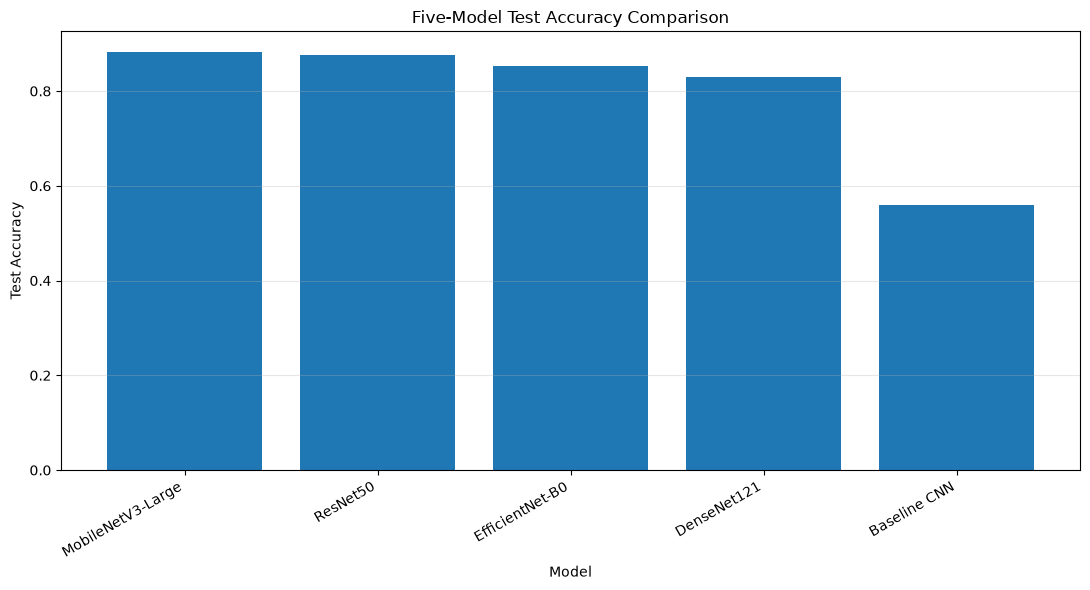

In [48]:
accuracy_plot_data = (
    model_comparison
    .sort_values(
        "test_accuracy",
        ascending=False,
    )
)

plt.figure(figsize=(11, 6))

plt.bar(
    accuracy_plot_data[
        "model_name"
    ],
    accuracy_plot_data[
        "test_accuracy"
    ],
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title(
    "Five-Model Test Accuracy Comparison"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

MODEL_ACCURACY_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "five_model_test_accuracy.png"
)

plt.savefig(
    MODEL_ACCURACY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## F1 Comparison

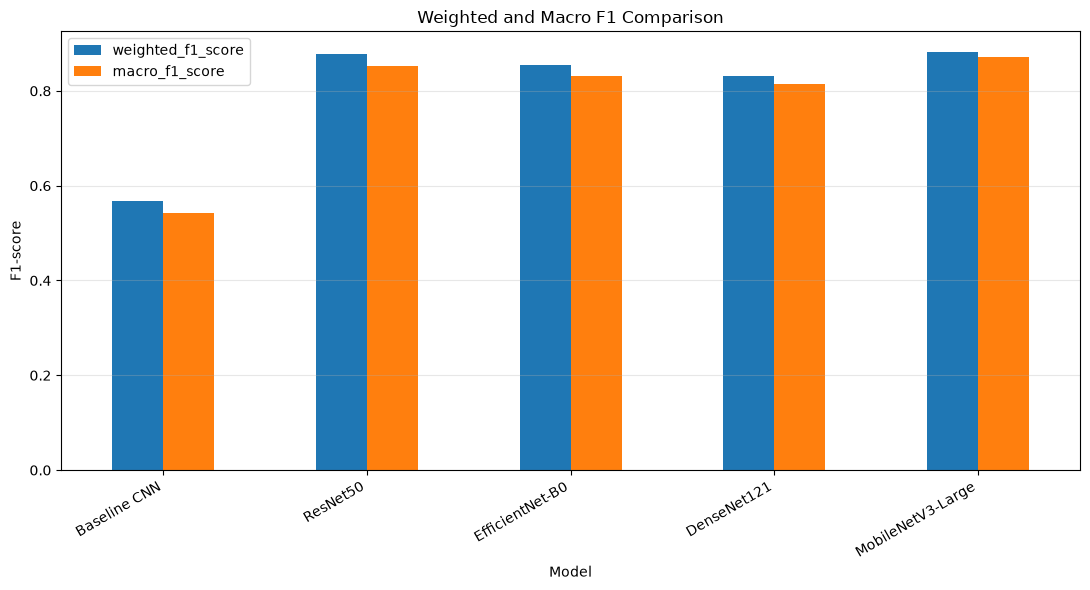

In [49]:
f1_plot_data = (
    model_comparison[
        [
            "model_name",
            "weighted_f1_score",
            "macro_f1_score",
        ]
    ]
    .set_index(
        "model_name"
    )
)

f1_plot_data.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title(
    "Weighted and Macro F1 Comparison"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

MODEL_F1_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "five_model_f1_comparison.png"
)

plt.savefig(
    MODEL_F1_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Accuracy versus Latency

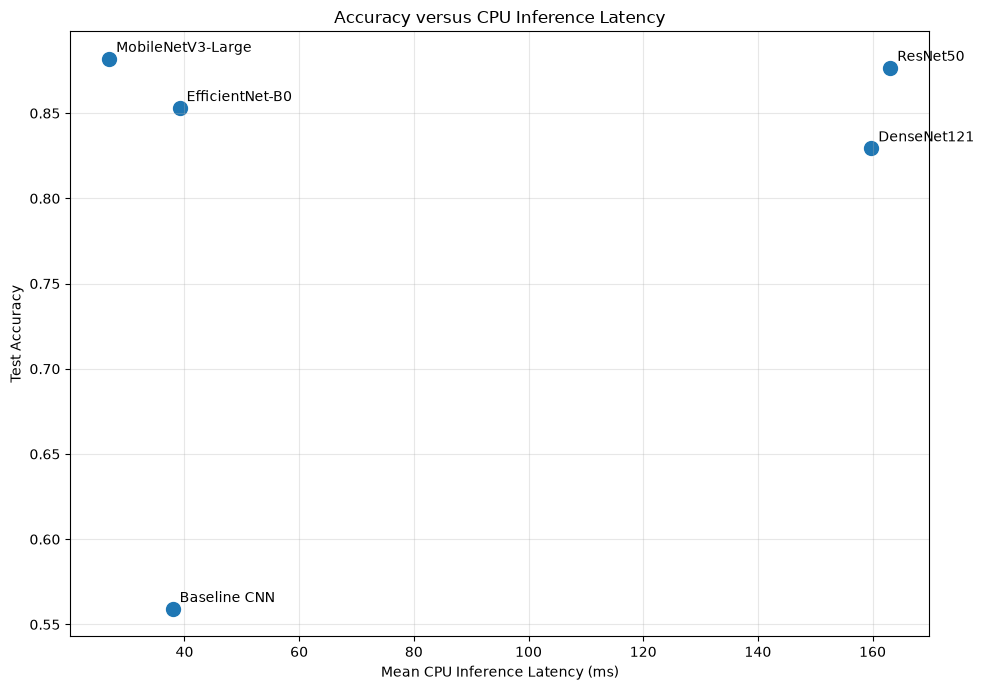

In [50]:
plt.figure(figsize=(10, 7))

plt.scatter(
    model_comparison[
        "mean_inference_latency_ms"
    ],
    model_comparison[
        "test_accuracy"
    ],
    s=100,
)

for _, row in (
    model_comparison.iterrows()
):
    plt.annotate(
        row["model_name"],
        (
            row[
                "mean_inference_latency_ms"
            ],
            row[
                "test_accuracy"
            ],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel(
    "Mean CPU Inference Latency (ms)"
)

plt.ylabel(
    "Test Accuracy"
)

plt.title(
    "Accuracy versus CPU Inference Latency"
)

plt.grid(alpha=0.3)
plt.tight_layout()

ACCURACY_LATENCY_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "accuracy_vs_latency.png"
)

plt.savefig(
    ACCURACY_LATENCY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [51]:
predictive_candidate = (
    predictive_ranking.iloc[0][
        "model_name"
    ]
)

efficiency_candidate = (
    deployment_ranking.iloc[0][
        "model_name"
    ]
)

selected_candidates = list(
    dict.fromkeys(
        [
            predictive_candidate,
            efficiency_candidate,
        ]
    )
)

if len(selected_candidates) < 2:
    selected_candidates.append(
        predictive_ranking.iloc[1][
            "model_name"
        ]
    )

print(
    "Candidates selected for "
    "hyperparameter optimization:"
)

for candidate in selected_candidates:
    print(f"- {candidate}")

Candidates selected for hyperparameter optimization:
- MobileNetV3-Large
- ResNet50
